In [1]:
import pandas as pd
import numpy as np

# ── 1. 데이터 로드 ──────────────────────────────────────────────────
df = pd.read_csv(
    "MiningProcess_Flotation_Plant_Database.csv",
    decimal=",",
    thousands="."
)

# ── 2. 시간 인덱스 설정 ──────────────────────────────────────────────
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d %H:%M:%S")
df = df.set_index("date")
df.index.name = "date"

# ── 3. 데이터 검증 ──────────────────────────────────────────────────
print("=" * 60)
print("df.info()")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("df.head()")
print("=" * 60)
display(df.head())

# ── 4. 결측치 확인 ──────────────────────────────────────────────────
missing = df.isnull().sum()
missing_cols = missing[missing > 0]
print("\n" + "=" * 60)
print(f"결측치 컬럼 수: {len(missing_cols)}")
if len(missing_cols) > 0:
    print(missing_cols)
else:
    print("결측치 없음")

# ── 5. 선형 보간법으로 결측치 처리 ─────────────────────────────────
df = df.interpolate(method="linear")
df = df.ffill().bfill()

print("\n보간 후 잔여 결측치:", df.isnull().sum().sum())

# ── 6. 데이터 타입 요약 ──────────────────────────────────────────────
non_float = df.select_dtypes(exclude="float64")
if non_float.shape[1] > 0:
    print("\n⚠ float64가 아닌 컬럼:")
    print(non_float.dtypes)
else:
    print("\n모든 수치 컬럼이 float64로 정상 인식되었습니다.")

print(f"\n최종 데이터 형태: {df.shape[0]}행 × {df.shape[1]}열")
print(f"시간 범위: {df.index.min()} ~ {df.index.max()}")

df.info()
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 737453 entries, 2017-03-10 01:00:00 to 2017-09-09 23:00:00
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   % Iron Feed                   737453 non-null  float64
 1   % Silica Feed                 737453 non-null  float64
 2   Starch Flow                   737453 non-null  float64
 3   Amina Flow                    737453 non-null  float64
 4   Ore Pulp Flow                 737453 non-null  float64
 5   Ore Pulp pH                   737453 non-null  float64
 6   Ore Pulp Density              737453 non-null  float64
 7   Flotation Column 01 Air Flow  737453 non-null  float64
 8   Flotation Column 02 Air Flow  737453 non-null  float64
 9   Flotation Column 03 Air Flow  737453 non-null  float64
 10  Flotation Column 04 Air Flow  737453 non-null  float64
 11  Flotation Column 05 Air Flow  737453 non-null  float64
 12  

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3047.36,568.665,397.939,10.0689,1.74,249.917,254.487,250.049,...,251.147,452.441,458.165,442.865,446.210,471.411,437.690,427.669,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3033.69,558.167,400.254,10.0697,1.74,250.203,252.136,249.895,...,248.928,452.441,452.900,450.523,453.670,462.598,443.682,425.679,66.91,1.31



결측치 컬럼 수: 0
결측치 없음

보간 후 잔여 결측치: 0

모든 수치 컬럼이 float64로 정상 인식되었습니다.

최종 데이터 형태: 737453행 × 23열
시간 범위: 2017-03-10 01:00:00 ~ 2017-09-09 23:00:00


In [2]:
# ── 1시간 리샘플링 (NaN 보존형) ──────────────────────────────────────

# Step 1: 1시간 평균 계산 (데이터 있는 구간만)
df_hourly = df.resample('1H').mean()

# Step 2: 빈 시간대를 NaN 행으로 채움 (보간 없음)
df_hourly = df_hourly.asfreq('1H')

# ── 결과 확인 ────────────────────────────────────────────────────────
print(f"리샘플링 전: {df.shape[0]}행")
print(f"리샘플링 후: {df_hourly.shape[0]}행")

print("\n" + "=" * 60)
print("공백 구간 NaN 확인: 2017-03-16 04:00 ~ 07:00")
print("=" * 60)
display(df_hourly.loc['2017-03-16 04:00:00':'2017-03-16 07:00:00'])

리샘플링 전: 737453행
리샘플링 후: 4415행

공백 구간 NaN 확인: 2017-03-16 04:00 ~ 07:00


C:\Users\USER\AppData\Local\Temp\ipykernel_22640\420523922.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean()
C:\Users\USER\AppData\Local\Temp\ipykernel_22640\420523922.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_hourly.asfreq('1H')


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-16 04:00:00,57.45,12.95,1537.229973,340.337976,399.935861,9.118414,1.547622,250.005594,250.238456,250.014767,...,250.045644,573.522806,583.528939,573.996783,507.093481,508.679939,507.729139,505.955369,65.39,2.35
2017-03-16 05:00:00,57.45,12.95,3575.411611,346.455938,401.212367,9.247818,1.598467,250.014961,249.743172,249.991178,...,250.070994,578.856128,590.143072,559.789306,494.788983,492.192189,499.902194,494.284172,64.03,3.78
2017-03-16 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03-16 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── 공학 지표 컬럼 생성 ───────────────────────────────────────────────────────
#
# 순서: Y → Rm/Jg 계산 → Rm/Jg 클리핑 → SI 계산 → SI 윈저라이징
# (클리핑 후 SI 계산해야 이상값이 SI에 전파되지 않음)
# ────────────────────────────────────────────────────────────────────────────

Feed_Fe = df_hourly['% Iron Feed']
Conc_Fe = df_hourly['% Iron Concentrate']
Feed_Si = df_hourly['% Silica Feed']
Conc_Si = df_hourly['% Silica Concentrate']

# ── Step 1. 수율 Y (mass balance) ────────────────────────────────────────────
denom_Y = (Conc_Fe - 15.0).replace(0, np.nan)
Y = (Feed_Fe - 15.0) / denom_Y

# ── Step 2. Rm (철 회수율) / Jg (실리카 제거율) ───────────────────────────────
Rm_raw = Y * (Conc_Fe / Feed_Fe) * 100
Jg_raw = (1 - Y * (Conc_Si / Feed_Si)) * 100

# ── Step 3. 물리적 범위 클리핑 [0, 100] ──────────────────────────────────────
df_hourly['Rm'] = Rm_raw.clip(0, 100)
df_hourly['Jg'] = Jg_raw.clip(0, 100)

# ── Step 4. 클리핑된 Rm/Jg로 SI 계산 ─────────────────────────────────────────
Rm = df_hourly['Rm']
Jg = df_hourly['Jg']

si_num   = Rm * Jg
si_denom = (100.1 - Rm) * (100.1 - Jg)
si_denom = si_denom.replace(0, np.nan)
si_inner = (si_num / si_denom).clip(lower=0)
df_hourly['SI'] = np.sqrt(si_inner)

# ── Step 5. SI 윈저라이징 (99th percentile) ───────────────────────────────────
si_99 = df_hourly['SI'].quantile(0.99)
df_hourly['SI'] = df_hourly['SI'].clip(upper=si_99)

# ── 검증 ──────────────────────────────────────────────────────────────────────
print("=" * 60)
print("Rm / Jg / SI 최종 통계량 (클리핑 + 윈저라이징 후)")
print("=" * 60)
display(df_hourly[['Rm', 'Jg', 'SI']].describe())

print(f"\nSI 윈저라이징 기준값 (99th pct): {si_99:.4f}")

print("\n" + "=" * 60)
print("공백 구간 NaN 유지 확인 (3/16 ~ 3/29)")
print("=" * 60)
gap = df_hourly.loc['2017-03-16':'2017-03-29', ['Rm', 'Jg', 'SI']]
print(f"전체 행 수  : {len(gap)}")
print(f"NaN 행 수   : {gap.isna().all(axis=1).sum()}")
print(f"유효 행 수  : {gap.notna().all(axis=1).sum()}")

Rm / Jg / SI 최종 통계량 (클리핑 + 윈저라이징 후)


,Rm,Jg,SI
count,4097.000000,4097.000000,4097.000000
mean,95.041206,82.635701,13.628375
std,3.249877,14.039635,4.951906
min,83.978543,0.000000,0.000000
25%,93.064259,77.213505,10.261423
50%,95.267551,86.385721,12.669536
75%,97.389686,92.610214,15.625473
max,100.000000,98.445799,32.891306



SI 윈저라이징 기준값 (99th pct): 32.8913

공백 구간 NaN 유지 확인 (3/16 ~ 3/29)
전체 행 수  : 336
NaN 행 수   : 318
유효 행 수  : 18


In [4]:
display(df_hourly.head())

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate,Rm,Jg,SI
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3162.625026,578.786678,398.753368,10.113487,1.729558,251.166672,250.226086,250.178287,...,450.474523,449.912259,455.792161,464.383310,450.532747,66.91,1.31,93.870034,94.025403,15.271599
2017-03-10 02:00:00,55.2,16.98,3133.256389,537.219661,399.871822,10.129742,1.667784,249.880589,250.214050,250.033317,...,450.081222,450.328806,448.722983,455.501528,451.387700,67.06,1.11,93.809401,94.952141,16.585029
2017-03-10 03:00:00,55.2,16.98,3479.482944,591.906744,398.763806,10.048403,1.732711,250.161328,250.104167,250.046350,...,450.901822,451.145822,451.134189,459.981311,450.296722,66.97,1.27,93.845739,94.214520,15.498414
2017-03-10 04:00:00,55.2,16.98,3228.036436,593.170106,399.866983,9.918614,1.731056,250.208772,250.204761,250.120861,...,487.387206,494.528183,495.664011,502.763850,494.939889,66.75,1.36,93.935098,93.778187,15.034222
2017-03-10 05:00:00,55.2,16.98,3327.280739,619.710806,399.615089,9.746029,1.765879,249.917800,250.160494,250.013500,...,549.459572,549.975483,549.512533,560.696300,550.271772,66.63,1.34,93.984160,93.855436,15.197703


## 3.x.3 미선물 철 함량 $t$ 민감도 분석

$t$ 값(10%~20%)에 따른 SI 변화 및 $t=15\%$ 기준 Pearson 상관계수 검토

  Table. t값에 따른 SI 기초 통계 및 t=15% 기준 Pearson 상관계수


,SI 평균,SI 표준편차,SI 최솟값,SI 최댓값,t=15% 대비 r
t 설정값 (%),,,,,
10%,16.99,5.56,0.0,36.86,0.9875
12%,15.44,5.29,0.0,35.26,0.9962
15%,13.63,4.95,0.0,32.89,1.0000
18%,12.23,4.71,0.0,31.78,0.9969
20%,11.45,4.59,0.0,31.29,0.9920


C:\Users\USER\AppData\Local\Temp\ipykernel_22640\4255160564.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(


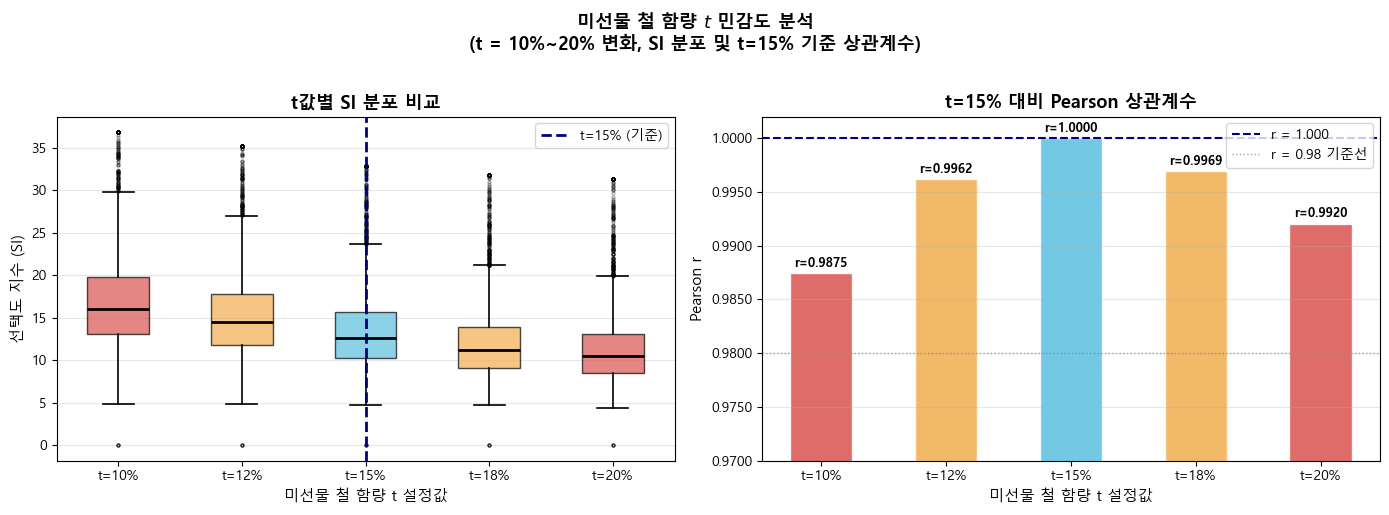

저장 완료: sensitivity_t_analysis.png


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["font.family"]        = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# ── 설정 ───────────────────────────────────────────────────────
f_Fe = df_hourly["% Iron Feed"]
c_Fe = df_hourly["% Iron Concentrate"]
f_Si = df_hourly["% Silica Feed"]
c_Si = df_hourly["% Silica Concentrate"]

t_values  = [10, 12, 15, 18, 20]
si_dict   = {}

for t in t_values:
    Y    = (f_Fe - t) / (c_Fe - t).replace(0, np.nan)
    Rm   = (Y * c_Fe / f_Fe * 100).clip(0, 100)
    Jg   = ((1 - Y * c_Si / f_Si) * 100).clip(0, 100)
    si99 = np.sqrt(Rm * Jg / ((100.1 - Rm) * (100.1 - Jg)))
    si99 = si99.clip(upper=si99.quantile(0.99))
    si_dict[t] = si99

si_df = pd.DataFrame(si_dict, index=df_hourly.index)

# ── 통계표 ─────────────────────────────────────────────────────
stats = []
for t in t_values:
    r = si_df[t].corr(si_df[15])
    stats.append({
        "t 설정값 (%)": f"{t}%",
        "SI 평균":      round(si_df[t].mean(), 2),
        "SI 표준편차":  round(si_df[t].std(),  2),
        "SI 최솟값":    round(si_df[t].min(),  2),
        "SI 최댓값":    round(si_df[t].max(),  2),
        "t=15% 대비 r": round(r, 4),
    })

stats_df = pd.DataFrame(stats).set_index("t 설정값 (%)")
print("=" * 65)
print("  Table. t값에 따른 SI 기초 통계 및 t=15% 기준 Pearson 상관계수")
print("=" * 65)
display(stats_df)

# ── 시각화 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① SI 박스플롯 비교
colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#f0ad4e", "#d9534f"]
bp = axes[0].boxplot(
    [si_df[t].dropna() for t in t_values],
    labels=[f"t={t}%" for t in t_values],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].axvline(x=3, color="navy", lw=2, ls="--", label="t=15% (기준)")
axes[0].set_title("t값별 SI 분포 비교", fontsize=13, fontweight="bold")
axes[0].set_xlabel("미선물 철 함량 t 설정값", fontsize=11)
axes[0].set_ylabel("선택도 지수 (SI)", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.3)

# ② 상관계수 막대그래프
rs     = [si_df[t].corr(si_df[15]) for t in t_values]
bar_colors = ["#d9534f", "#f0ad4e", "#5bc0de", "#f0ad4e", "#d9534f"]
bars   = axes[1].bar([f"t={t}%" for t in t_values], rs,
                     color=bar_colors, edgecolor="white",
                     alpha=0.85, width=0.5)
axes[1].set_ylim(0.97, 1.002)
axes[1].axhline(y=1.0, color="navy", lw=1.5, ls="--", label="r = 1.000")
axes[1].axhline(y=0.98, color="gray", lw=1.0, ls=":", alpha=0.7, label="r = 0.98 기준선")
axes[1].set_title("t=15% 대비 Pearson 상관계수", fontsize=13, fontweight="bold")
axes[1].set_xlabel("미선물 철 함량 t 설정값", fontsize=11)
axes[1].set_ylabel("Pearson r", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3)
axes[1].yaxis.set_major_formatter(ticker.FormatStrFormatter("%.4f"))

for bar, r in zip(bars, rs):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.0003,
        f"r={r:.4f}", ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

plt.suptitle(
    "미선물 철 함량 $t$ 민감도 분석\n(t = 10%~20% 변화, SI 분포 및 t=15% 기준 상관계수)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("sensitivity_t_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print("저장 완료: sensitivity_t_analysis.png")


=== t값별 SI 기초 통계 ===
           t=10%      t=12%      t=15%      t=18%      t=20%
count  4097.0000  4097.0000  4097.0000  4097.0000  4097.0000
mean     17.0535    15.5042    13.7095    12.3160    11.5360
std       5.8433     5.6175     5.3604     5.1664     5.0612
min       0.0000     0.0000     0.0000     0.0000     0.0000
25%      13.0439    11.7450    10.2614     9.1094     8.4729
50%      16.0838    14.4893    12.6695    11.2505    10.4665
75%      19.7608    17.8423    15.6255    13.9475    13.0303
max      59.4139    59.3847    59.3364    59.2818    59.2412

=== t=15% 기준 Pearson 상관계수 ===
  t=15% vs t=10%: r = 0.985511
  t=15% vs t=12%: r = 0.995506
  t=15% vs t=15%: r = 1.000000
  t=15% vs t=18%: r = 0.996785
  t=15% vs t=20%: r = 0.991822


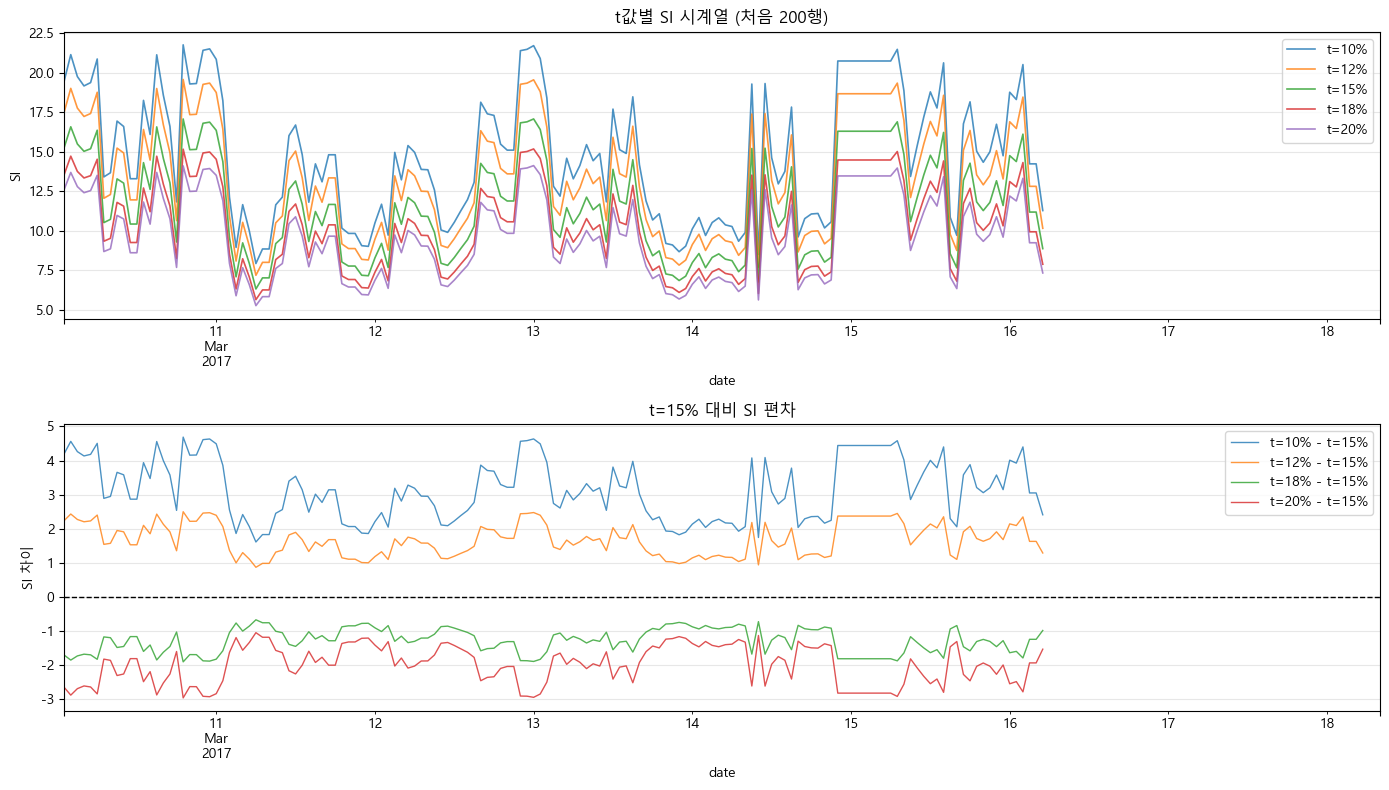

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

f_Fe = df_hourly["% Iron Feed"]
c_Fe = df_hourly["% Iron Concentrate"]
f_Si = df_hourly["% Silica Feed"]
c_Si = df_hourly["% Silica Concentrate"]

t_values = [10, 12, 15, 18, 20]
si_results = {}

for t in t_values:
    Y    = (f_Fe - t) / (c_Fe - t).replace(0, np.nan)
    Rm   = (Y * c_Fe / f_Fe * 100).clip(0, 100)
    Jg   = ((1 - Y * c_Si / f_Si) * 100).clip(0, 100)
    si   = np.sqrt(Rm * Jg / ((100.1 - Rm) * (100.1 - Jg)))
    si_results[f"t={t}%"] = si

si_df = pd.DataFrame(si_results, index=df_hourly.index)

# ── 상관관계 확인 (t=15 기준) ──────────────────────────────────
print("=== t값별 SI 기초 통계 ===")
print(si_df.describe().round(4))

print("\n=== t=15% 기준 Pearson 상관계수 ===")
for col in si_df.columns:
    r = si_df["t=15%"].corr(si_df[col])
    print(f"  t=15% vs {col}: r = {r:.6f}")

# ── 시계열 비교 플롯 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 절대값 비교
si_df.iloc[:200].plot(ax=axes[0], lw=1.2, alpha=0.8)
axes[0].set_title("t값별 SI 시계열 (처음 200행)")
axes[0].set_ylabel("SI")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# t=15 대비 편차
for col in [c for c in si_df.columns if c != "t=15%"]:
    diff = si_df[col] - si_df["t=15%"]
    diff.iloc[:200].plot(ax=axes[1], label=f"{col} - t=15%", lw=1.0, alpha=0.8)
axes[1].axhline(0, color="black", lw=1.0, ls="--")
axes[1].set_title("t=15% 대비 SI 편차")
axes[1].set_ylabel("SI 차이")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("si_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()